# **Binary Classification of Fatal vs. Non-Fatal Traffic Collision Events in Ottawa**

## Goal
The goal of this project is to develop a supervised machine learning model capable of classifying traffic collisions as fatal or non-fatal based on historical collision data.

## Dataset
The traffic collision dataset can be found in the Open Ottawa portal (https://open.ottawa.ca/datasets/ottawa::traffic-collision-data/about)

## Data Dictionary:

* **X:** X coordinate 
* **Y:** Y coordinate 
* **X_Coodinate:** X coordinate (MTM Zone 9, NAD83)
* **Y_Coodinate:** Y coordinate (MTM Zone 9, NAD83)
* **ID:** Collision record identifier
* **Geo_ID:** Geographic identifier for the collision location
* **Accident_Year:** Year of the collision
* **Accident_Date:** Date of the collision
* **Location:** Location of collision (RD1 @ RD2 or RD from RD 1 to RD 2)
* **Classification_Of_Accident:** Type/ category of collision (non-fatal, fatal, property damage only)
* **Initial_Impact_Type:** Impact type of collision (Angle, turning movement, rear-end…)
* **Road_1_Surface_Condition:** Surface condition of the road at the collision location (Ice, wet, dry snow...)
* **Environment_Condition_1:** Environmental or weather-related condition at the time of collision (Clear, rain, snow…)
* **Light:** Lighting condition at time of accident (daylight, dawn, dusk…)
* **Traffic_Control:** Traffic control present at site (stop, traffic signal, no control…)
* **num_of_vehicles:** Number of vehicles involved
* **num_of_pedestrians:** Number of pedestrians involved
* **num_of_bicycles:** Number of bicycles involved
* **num_of_motorcycles:** Number of motorcycles involved
* **Max_injury:** Highest injury level/ severity in the collision 
* **num_of_injuries:** Number of injured people involved
* **num_of_minimal:** Number of minimal injuries involved (Person did not go to hospital when leaving the scene of the collision)
* **num_of_minor:** Number of minor injuries involved (Person went to hospital and was treated in the emergency room, but not admitted)
* **num_of_major:** Number of major injuries involved (Person admitted to hospital. Includes person admitted for observation. This could be either life threatening or non-life threatening)
* **num_of_fatal:** Number of fatal injuries involved (Person killed immediately or within 30 days of the motor vehicle collision)
* **Lat:**  Latitude of collision (WGS1984)
* **Long:**  Longitude of collision (WGS1984)
* **ObjectId:** Object ID

## **Exploratory Data Analysis (EDA)**

## Loading all the necessary packages

In [1]:
# Import libraries
import pandas as pd
pd.set_option('display.max_columns', 100)
import numpy as np

# matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Import the dataset

In [2]:
# Load 'Traffic_Collision_Data.csv' in a pandas dataframe 'df'
df = pd.read_csv('Traffic_Collision_Data.csv')

In [3]:
df.head()

,X,Y,X_Coordinate,Y_Coordinate,ID,Geo_ID,Accident_Year,Accident_Date,Location,Classification_Of_Accident,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
0,-8.449907e+06,5.674412e+06,351293.8071,5021841.110,2017--101,__3Z00RNB,2017,1/4/2017,MARCH RD btwn 280 S OF CARLING AVE/STATION RD ...,02 - Non-fatal injury,02 - Angle,03 - Loose snow,03 - Snow,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,Minimal,1.0,1.0,NaN,NaN,NaN,45.334978,-75.906802,1
1,-8.432341e+06,5.664915e+06,363723.6849,5015276.436,2017--201,0004726,2017,1/5/2017,GREENBANK RD @ BERRIGAN DR/WESSEX RD (0004726),03 - P.D. only,05 - Turning movement,02 - Wet,01 - Clear,07 - Dark,01 - Traffic signal,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.274975,-75.749006,2
2,-8.427552e+06,5.687484e+06,366942.7019,5031143.575,2017--801,0006357,2017,1/23/2017,ALBERT ST @ BAY ST (0006357),02 - Non-fatal injury,07 - SMV other,01 - Dry,01 - Clear,07 - Dark,01 - Traffic signal,1.0,1.0,NaN,NaN,Minimal,1.0,1.0,NaN,NaN,NaN,45.417468,-75.705989,3
3,-8.423618e+06,5.682501e+06,369744.7181,5027678.543,2017--102,0001586,2017,1/4/2017,KILBORN AVE/KILBORN PL @ LAMIRA ST (0001586),03 - P.D. only,01 - Approaching,06 - Ice,03 - Snow,05 - Dusk,11 - Roundabout,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.386036,-75.670647,4
4,-8.421028e+06,5.632923e+06,371935.0538,4992842.240,2017--103,__3Z09V2,2017,1/4/2017,DONNELLY DR btwn FAIRMILE RD & FOURTH LINE RD ...,03 - P.D. only,04 - Sideswipe,03 - Loose snow,03 - Snow,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.072377,-75.647379,5


In [4]:
df.tail()

,X,Y,X_Coordinate,Y_Coordinate,ID,Geo_ID,Accident_Year,Accident_Date,Location,Classification_Of_Accident,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
94401,-8.427386e+06,5.685407e+06,367073.7930,5029688.610,2024--116742,__3Z08HP,2024,7/2/2024,HIGHWAY 417 btwn HWY417 IC121A RAMP16 & HWY417...,03 - P.D. only,04 - Sideswipe,01 - Dry,01 - Clear,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.404365,-75.704498,94402
94402,-8.433746e+06,5.679108e+06,362641.9980,5025229.937,2024--116743,__3Z07G2,2024,7/2/2024,HIGHWAY 417 btwn HWY417 IC127 RAMP25 & HWY417 ...,03 - P.D. only,04 - Sideswipe,01 - Dry,01 - Clear,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.364626,-75.761629,94403
94403,-8.405093e+06,5.679028e+06,382806.1930,5025390.965,2024--116744,__3Z07FS,2024,7/2/2024,HIGHWAY 417 btwn HWY417 IC104 RAMP15 & HWY417 ...,03 - P.D. only,07 - SMV other,01 - Dry,01 - Clear,05 - Dusk,10 - No control,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.364121,-75.504235,94404
94404,-8.454695e+06,5.666662e+06,347959.6632,5016376.581,2024--116745,__3Z08SK,2024,7/3/2024,HIGHWAY 417 btwn HWY417 IC144 RAMP61 & HWY417 ...,03 - P.D. only,07 - SMV other,01 - Dry,01 - Clear,07 - Dark,10 - No control,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.286019,-75.949815,94405
94405,-8.437484e+06,5.676273e+06,360029.1353,5023217.297,2024--116746,__3Z08R0,2024,7/3/2024,HIGHWAY 417 btwn HIGHWAY 417 & HWY417 IC129 RA...,03 - P.D. only,03 - Rear end,01 - Dry,01 - Clear,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.346727,-75.795205,94406


In [5]:
df.sample(5)

,X,Y,X_Coordinate,Y_Coordinate,ID,Geo_ID,Accident_Year,Accident_Date,Location,Classification_Of_Accident,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
32267,-8.448447e+06,5.673956e+06,352323.6230,5021528.488,2019--32110,0003170,2019,3/4/2019,HERZBERG RD @ MARCH RD (0003170),02 - Non-fatal injury,05 - Turning movement,01 - Dry,01 - Clear,07 - Dark,01 - Traffic signal,2.0,NaN,NaN,NaN,Minor,3.0,NaN,3.0,NaN,NaN,45.332096,-75.893694,32268
11445,-8.425680e+06,5.685411e+06,368273.7090,5029703.561,2017--11653,0007233,2017,12/14/2017,BANK ST @ FIRST AVE (0007233),03 - P.D. only,04 - Sideswipe,02 - Wet,01 - Clear,01 - Daylight,01 - Traffic signal,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.404392,-75.689170,11446
10288,-8.417875e+06,5.682867e+06,373781.6048,5027977.975,2017--10786,__3Z08XY,2017,11/26/2017,WALKLEY RD btwn HALIFAX DR & ST. LAURENT BLVD ...,03 - P.D. only,03 - Rear end,03 - Loose snow,03 - Snow,07 - Dark,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.388344,-75.619060,10289
44395,-8.387979e+06,5.674558e+06,394894.5219,5022415.522,2019--44323,__3Z05ML,2019,5/4/2019,HWY417 IC88 RAMP51 btwn HIGHWAY 417 & ROCKDALE...,03 - P.D. only,07 - SMV other,01 - Dry,01 - Clear,07 - Dark,10 - No control,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.335902,-75.350496,44396
92340,-8.418028e+06,5.680791e+06,373690.0919,5026521.227,2024--114447,__4LVLEY,2024,11/18/2024,GRANDPARK CIR btwn GRANDPARK CIR & GRANDPARK C...,04 - Non-reportable,07 - SMV other,01 - Dry,01 - Clear,07 - Dark,10 - No control,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.375246,-75.620432,92341


### We checked the head, tail and sample of the dataset. We can already see that there are NaN values.

In [6]:
# Check the number of columns and rows
df.shape

(94406, 28)

### There are a total of 28 columns and 94,406 rows.

In [7]:
df.describe()

,X,Y,X_Coordinate,Y_Coordinate,Accident_Year,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
count,9.440600e+04,9.440600e+04,94406.000000,9.440600e+04,94406.000000,94238.000000,1831.000000,1665.00000,791.000000,15223.000000,6590.000000,8656.000000,817.000000,169.000000,94406.000000,94406.000000,94406.000000
mean,-8.427894e+06,5.675457e+06,366681.116243,5.021918e+06,2020.132439,1.866349,1.038777,1.00961,1.015171,1.293438,1.208194,1.219616,1.112607,1.065089,45.334280,-75.709057,47203.500000
std,1.753820e+04,1.571708e+05,13998.163610,1.389519e+05,2.367294,0.564350,0.204120,0.10921,0.132254,0.719960,0.554833,0.576199,0.583305,0.270406,1.254323,0.157548,27252.809094
min,-8.820655e+06,0.000000e+00,0.000000,0.000000e+00,2017.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-79.237290,1.000000
25%,-8.432998e+06,5.674030e+06,363180.599300,5.021664e+06,2018.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.332566,-75.754909,23602.250000
50%,-8.426562e+06,5.681332e+06,367649.068150,5.026852e+06,2020.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.378657,-75.697095,47203.500000
75%,-8.420494e+06,5.687625e+06,371921.717000,5.031271e+06,2022.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.418357,-75.642588,70804.750000
max,-8.378081e+06,5.704542e+06,401821.931000,5.043439e+06,2024.000000,25.000000,3.000000,3.00000,3.000000,38.000000,11.000000,10.000000,14.000000,3.000000,45.524921,-75.261583,94406.000000


### We can see that the dataset contains data from 2017-2024.

## Check the data types

In [8]:
df.dtypes

X                             float64
Y                             float64
X_Coordinate                  float64
Y_Coordinate                  float64
ID                             object
Geo_ID                         object
Accident_Year                   int64
Accident_Date                  object
Location                       object
Classification_Of_Accident     object
Initial_Impact_Type            object
Road_1_Surface_Condition       object
Environment_Condition_1        object
Light                          object
Traffic_Control                object
num_of_vehicles               float64
num_of_pedestrians            float64
num_of_bicycles               float64
num_of_motorcycles            float64
Max_injury                     object
num_of_injuries               float64
num_of_minimal                float64
num_of_minor                  float64
num_of_major                  float64
num_of_fatal                  float64
Lat                           float64
Long        

### The Accident_Date column, currently stored as an object type, should be converted to a datetime format to enable temporal feature extraction. Features stored as floats may be converted to integers. The remaining object-type variables, such as environmental conditions, road surface, lighting, and traffic control, represent categorical features and will need to be encoded.

## Class Distribution Analysis

Text(0, 0.5, 'Number of Collisions')

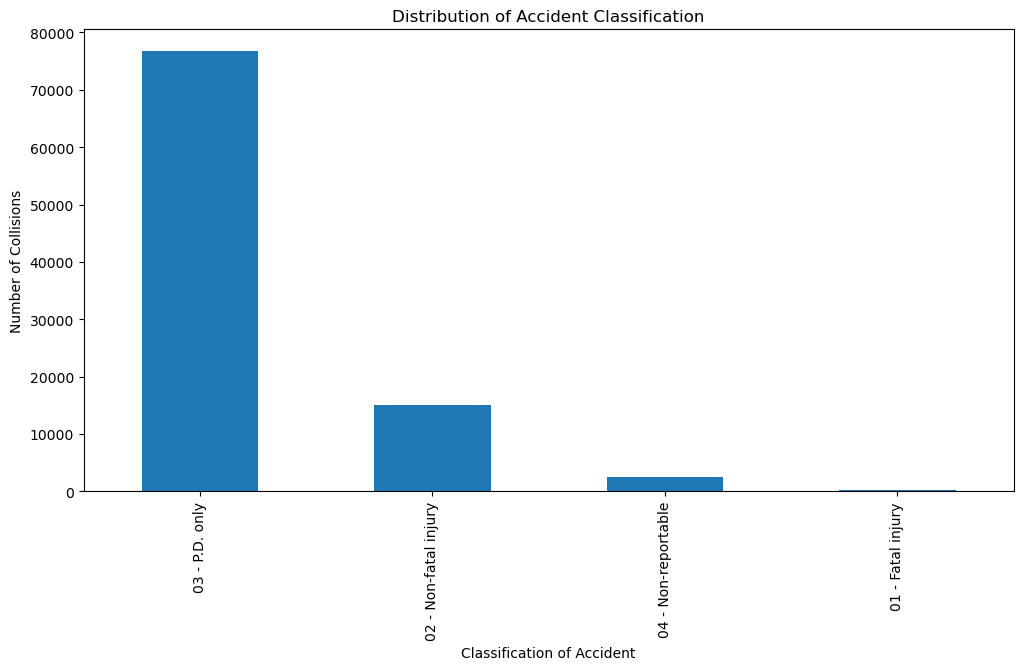

In [9]:
# Check target variable
df['Classification_Of_Accident'].value_counts().plot(kind='bar',figsize=(12, 6))

plt.title("Distribution of Accident Classification")
plt.xlabel("Classification of Accident")
plt.ylabel("Number of Collisions")

In [10]:
classification_counts = (df["Classification_Of_Accident"].value_counts())

percentage = (classification_counts / len(df) * 100).round(2)

class_distribution = pd.DataFrame({"Count": classification_counts, "Percent": percentage})

display(class_distribution)

,Count,Percent
Classification_Of_Accident,,
03 - P.D. only,76671,81.21
02 - Non-fatal injury,15002,15.89
04 - Non-reportable,2563,2.71
01 - Fatal injury,170,0.18


### The dataset contains 170 fatal accidents (approximately 0.18%), while the majority are non-fatal incidents, including property-damage-only (P.D.) and non-reportable cases (about 99.81%). This indicates a clear and severe class imbalance within the dataset. 

In [11]:
# Create a binary flag
df['fatal_flag'] = df['Classification_Of_Accident'].apply(lambda x: 1 if '01 - Fatal injury' in str(x) else 0)

# Create a label for fatal accidents
df['fatal_label'] = df['Classification_Of_Accident'].apply(lambda x: 'Fatal' if '01 - Fatal injury' in str(x) else 'Non-Fatal')

In [12]:
df['fatal_label'].value_counts()

fatal_label
Non-Fatal    94236
Fatal          170
Name: count, dtype: int64

Text(0, 0.5, 'Number of Collisions')

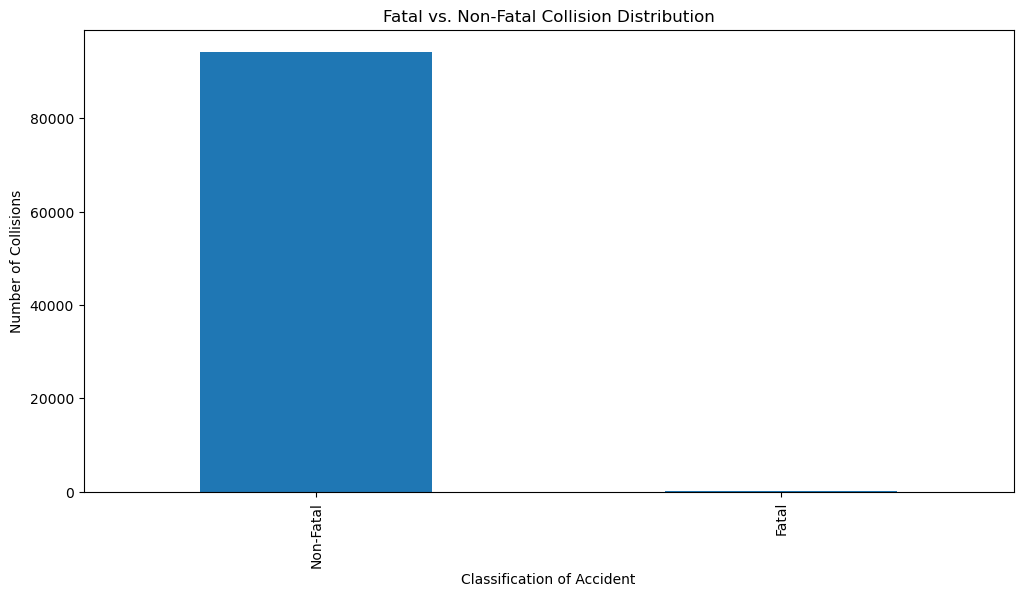

In [13]:
df['fatal_label'].value_counts().plot(kind='bar',figsize=(12, 6))

plt.title("Fatal vs. Non-Fatal Collision Distribution")
plt.xlabel("Classification of Accident")
plt.ylabel("Number of Collisions")

In [14]:
classification_counts = (df['fatal_label'].value_counts())

percentage = (classification_counts / len(df) * 100).round(2)

class_distribution = pd.DataFrame({"Count": classification_counts, "Percent": percentage})

display(class_distribution)

,Count,Percent
fatal_label,,
Non-Fatal,94236,99.82
Fatal,170,0.18


## Missing Values

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94406 entries, 0 to 94405
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   X                           94406 non-null  float64
 1   Y                           94406 non-null  float64
 2   X_Coordinate                94406 non-null  float64
 3   Y_Coordinate                94406 non-null  float64
 4   ID                          94406 non-null  object 
 5   Geo_ID                      92330 non-null  object 
 6   Accident_Year               94406 non-null  int64  
 7   Accident_Date               94406 non-null  object 
 8   Location                    92330 non-null  object 
 9   Classification_Of_Accident  94406 non-null  object 
 10  Initial_Impact_Type         94394 non-null  object 
 11  Road_1_Surface_Condition    94405 non-null  object 
 12  Environment_Condition_1     94393 non-null  object 
 13  Light                       943

In [16]:
# Check missing values for each variable
df.isnull().sum()

X                                 0
Y                                 0
X_Coordinate                      0
Y_Coordinate                      0
ID                                0
Geo_ID                         2076
Accident_Year                     0
Accident_Date                     0
Location                       2076
Classification_Of_Accident        0
Initial_Impact_Type              12
Road_1_Surface_Condition          1
Environment_Condition_1          13
Light                            14
Traffic_Control                  30
num_of_vehicles                 168
num_of_pedestrians            92575
num_of_bicycles               92741
num_of_motorcycles            93615
Max_injury                    79241
num_of_injuries               79183
num_of_minimal                87816
num_of_minor                  85750
num_of_major                  93589
num_of_fatal                  94237
Lat                               0
Long                              0
ObjectId                    

### A total of 17 columns have missing values.
Geo_ID, Location, Initial_Impact_Type, Road_1_Surface_Condition, Environment_Condition_1, Light, Traffic_Control, num_of_vehicles, num_of_pedestrians, num_of_bicycles, num_of_motorcycles, Max_injury, num_of_injuries, num_of_minimal, num_of_minor, num_of_major, and num_of_fatal.
- Participant count columns (such as pedestrians, bicycles, and motorcycles) are only filled in when those participants are involved in a collision. When values are missing, it typically means none were involved, so replacing them with zero is appropriate. A similar pattern appears in the injury-related columns.
- num_of_fatal column is also missing values, but we also see that this directly indicates whether a collision was fatal. Therefore, it must be removed before training the model to avoid data leakage.

## Feature vs. Severity Analysis


Environment vs. Fatality --------------------------------------------------
fatal_label                  Fatal  Non-Fatal  Fatality Percentage
Environment_Condition_1                                           
00 - Unknown                     0        121                 0.00
01 - Clear                     151      74321                 0.20
02 - Rain                        7       8254                 0.08
03 - Snow                        5       9193                 0.05
04 - Freezing Rain               1       1290                 0.08
05 - Drifting Snow               1        438                 0.23
06 - Strong wind                 1        146                 0.68
07 - Fog, mist, smoke, dust      2        278                 0.71
99 - Other                       1        183                 0.54


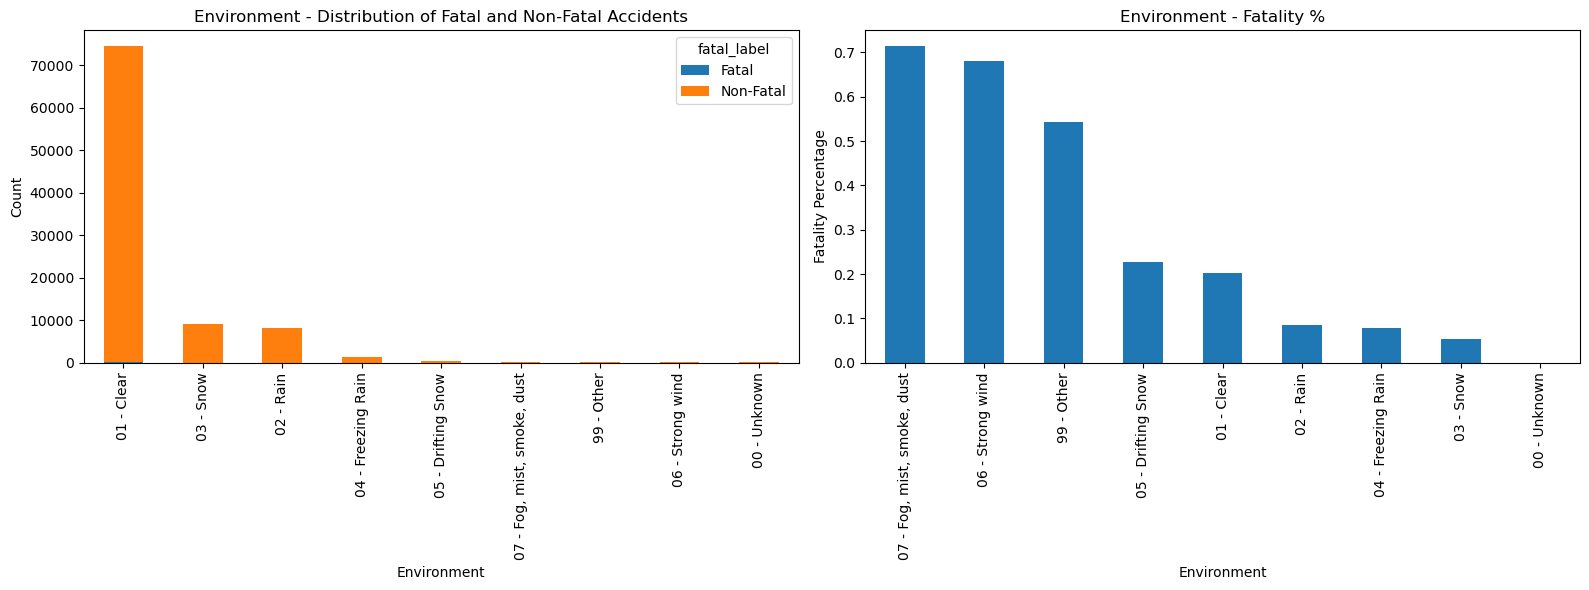


Road Surface vs. Fatality --------------------------------------------------
fatal_label                Fatal  Non-Fatal  Fatality Percentage
Road_1_Surface_Condition                                        
00 - Unknown                   1        100                 0.99
01 - Dry                     133      64038                 0.21
02 - Wet                      24      15630                 0.15
03 - Loose snow                3       5427                 0.06
04 - Slush                     2       3054                 0.07
05 - Packed snow               3       2363                 0.13
06 - Ice                       3       3437                 0.09
07 - Mud                       0         12                 0.00
08 - Loose sand or gravel      1         79                 1.25
09 - Spilled liquid            0         10                 0.00
99 - Other                     0         85                 0.00


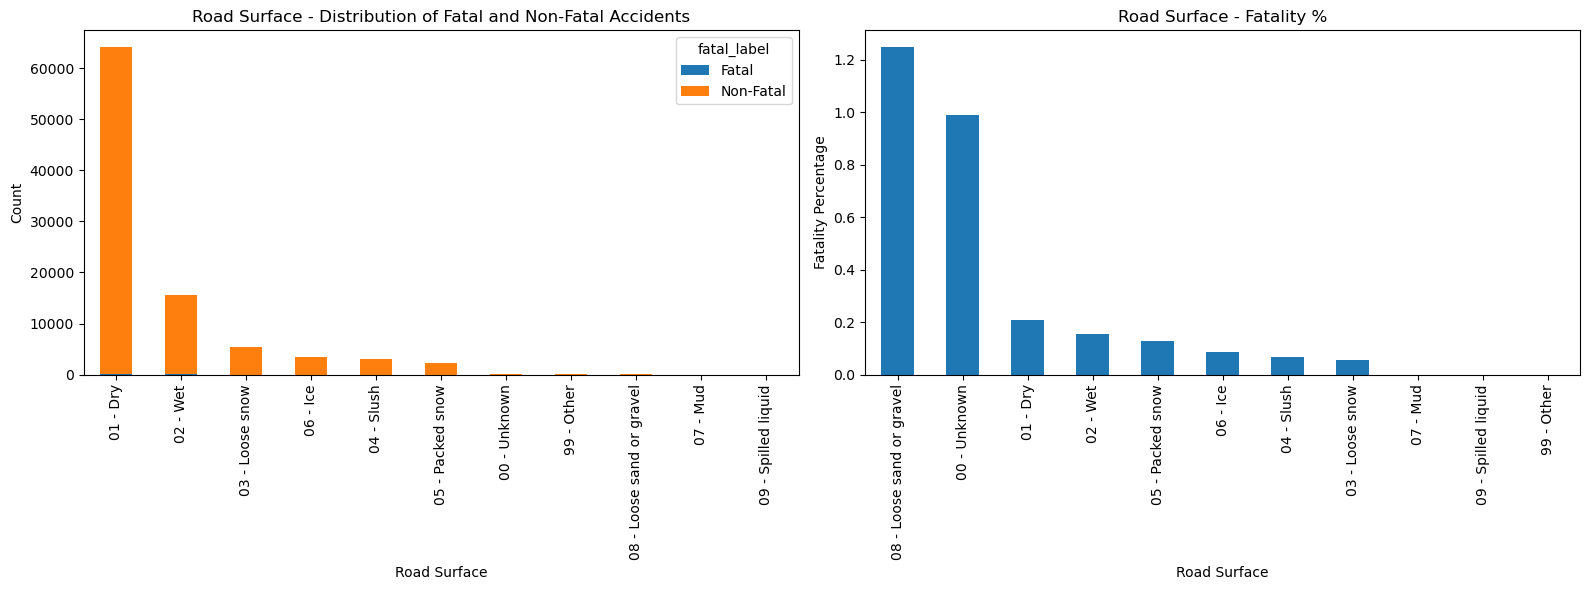


Lighting vs. Fatality --------------------------------------------------
fatal_label    Fatal  Non-Fatal  Fatality Percentage
Light                                               
00 - Unknown       0       2714                 0.00
01 - Daylight     89      63666                 0.14
03 - Dawn          7       2358                 0.30
05 - Dusk          8       4302                 0.19
07 - Dark         66      21141                 0.31
99 - Other         0         41                 0.00


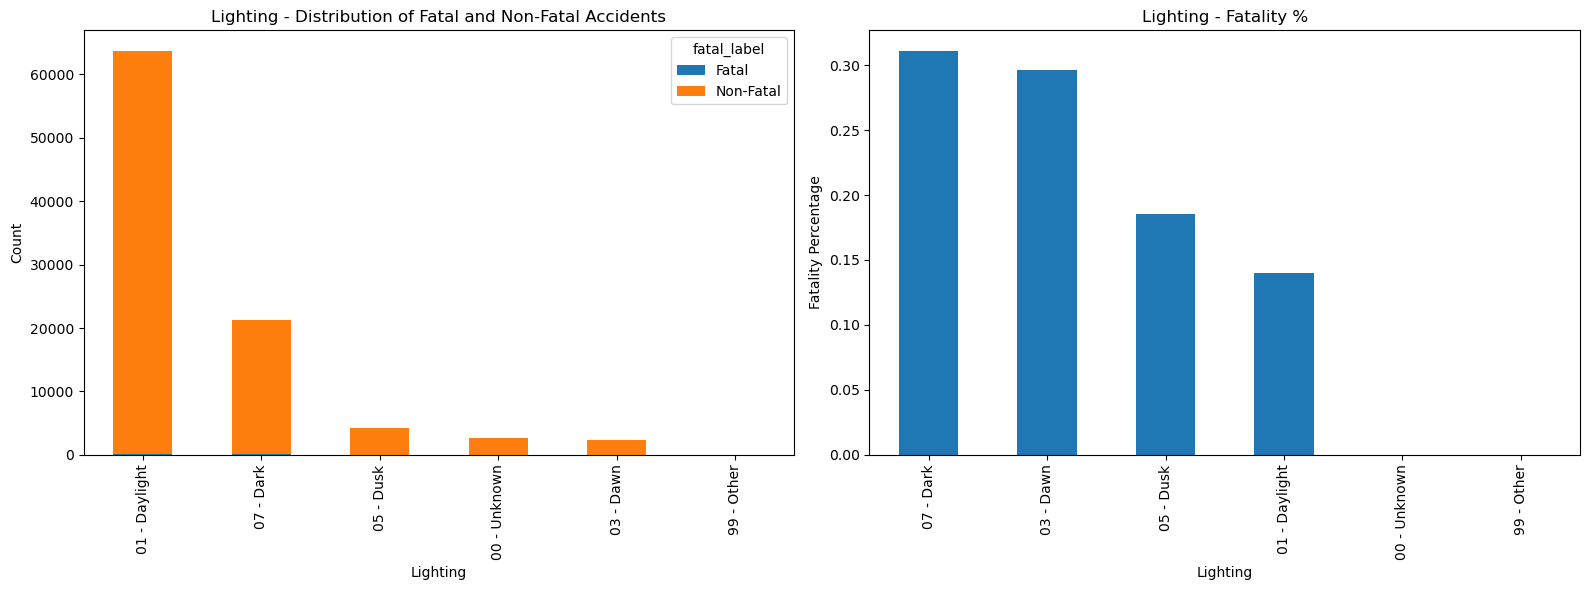


Impact Type vs. Fatality --------------------------------------------------
fatal_label                  Fatal  Non-Fatal  Fatality Percentage
Initial_Impact_Type                                               
01 - Approaching                19       1260                 1.49
02 - Angle                      23      11802                 0.19
03 - Rear end                    7      31713                 0.02
04 - Sideswipe                   2      13614                 0.01
05 - Turning movement           19      11145                 0.17
06 - SMV unattended vehicle      2       8204                 0.02
07 - SMV other                  92      14105                 0.65
99 - Other                       6       2381                 0.25


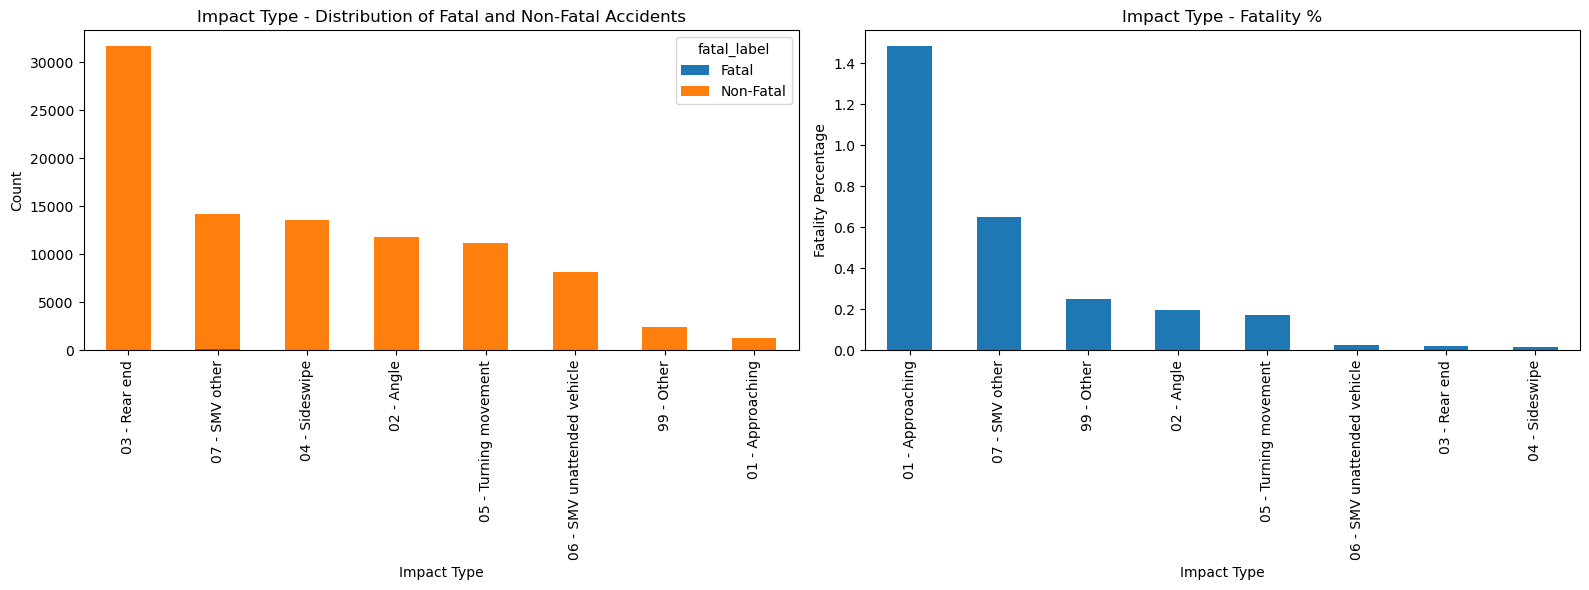


Traffic Control vs. Fatality --------------------------------------------------
fatal_label              Fatal  Non-Fatal  Fatality Percentage
Traffic_Control                                               
01 - Traffic signal         34      38216                 0.09
02 - Stop sign              31      10154                 0.30
03 - Yield sign              1        614                 0.16
04 - Ped. crossover          0         32                 0.00
05 - Police control          0          3                 0.00
06 - School guard            0          1                 0.00
07 - School bus              0          6                 0.00
08 - Traffic gate            1         11                 8.33
09 - Traffic controller      0         10                 0.00
10 - No control            102      43598                 0.23
11 - Roundabout              1       1308                 0.08
12 - IPS                     0        130                 0.00
13 - MPS                     0       

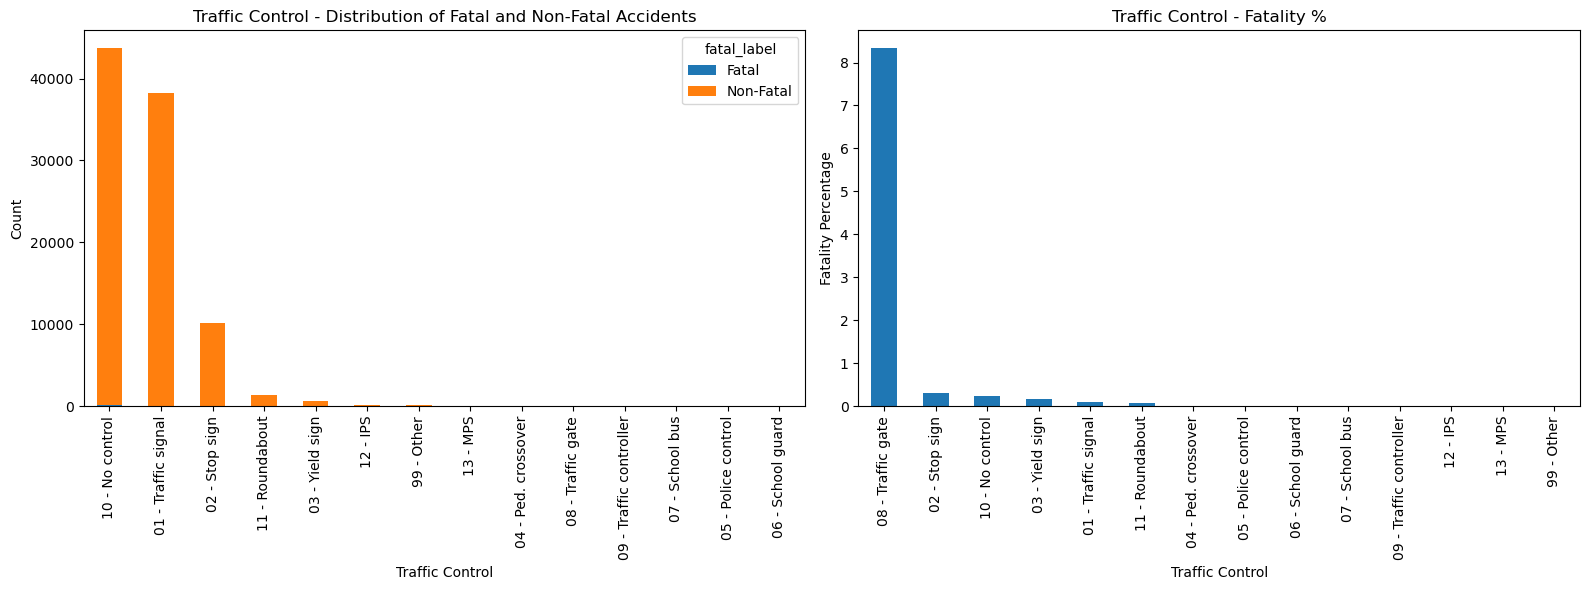


Number of Vehicles vs. Fatality --------------------------------------------------
fatal_label      Fatal  Non-Fatal  Fatality Percentage
num_of_vehicles                                       
1.0                 92      20186                 0.45
2.0                 66      67482                 0.10
3.0                 11       5412                 0.20
4.0                  0        799                 0.00
5.0                  0        141                 0.00
6.0                  0         31                 0.00
7.0                  0         12                 0.00
8.0                  0          3                 0.00
9.0                  0          2                 0.00
25.0                 0          1                 0.00


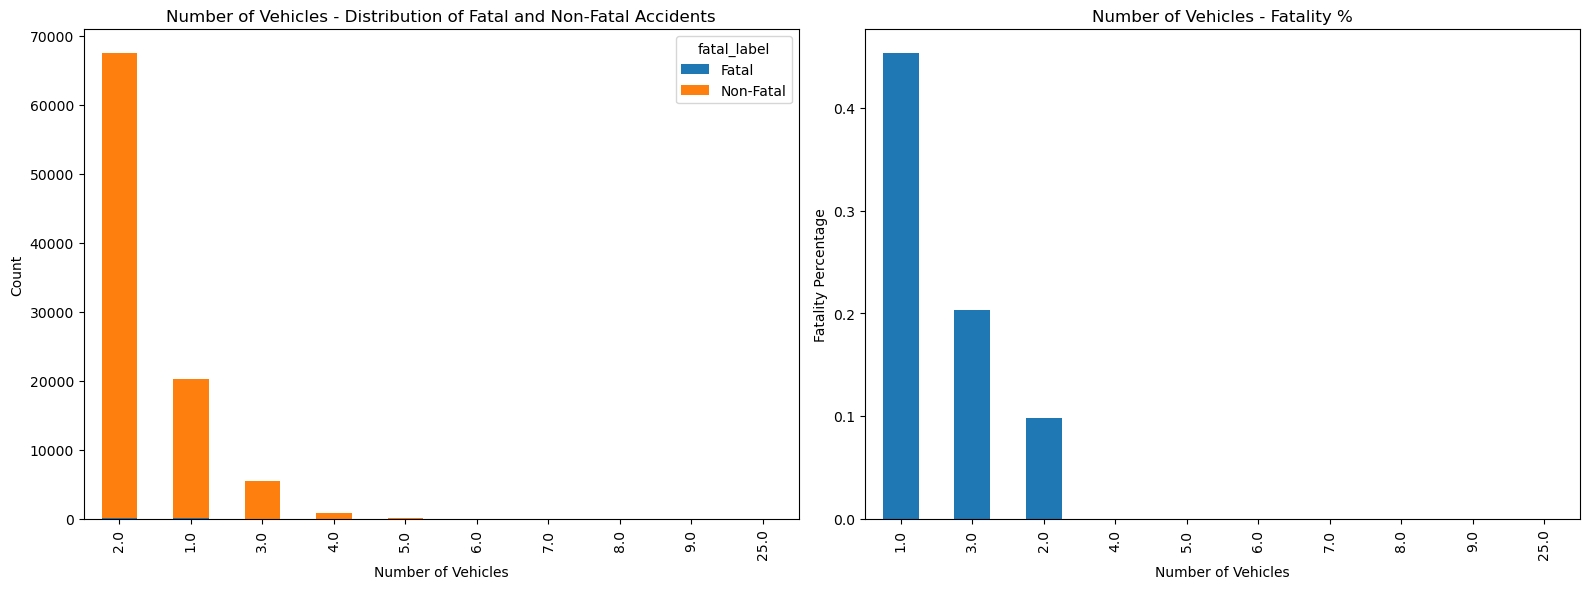


Number of Pedestrians vs. Fatality --------------------------------------------------
fatal_label         Fatal  Non-Fatal  Fatality Percentage
num_of_pedestrians                                       
1.0                    46       1718                 2.61
2.0                     2         61                 3.17
3.0                     0          4                 0.00


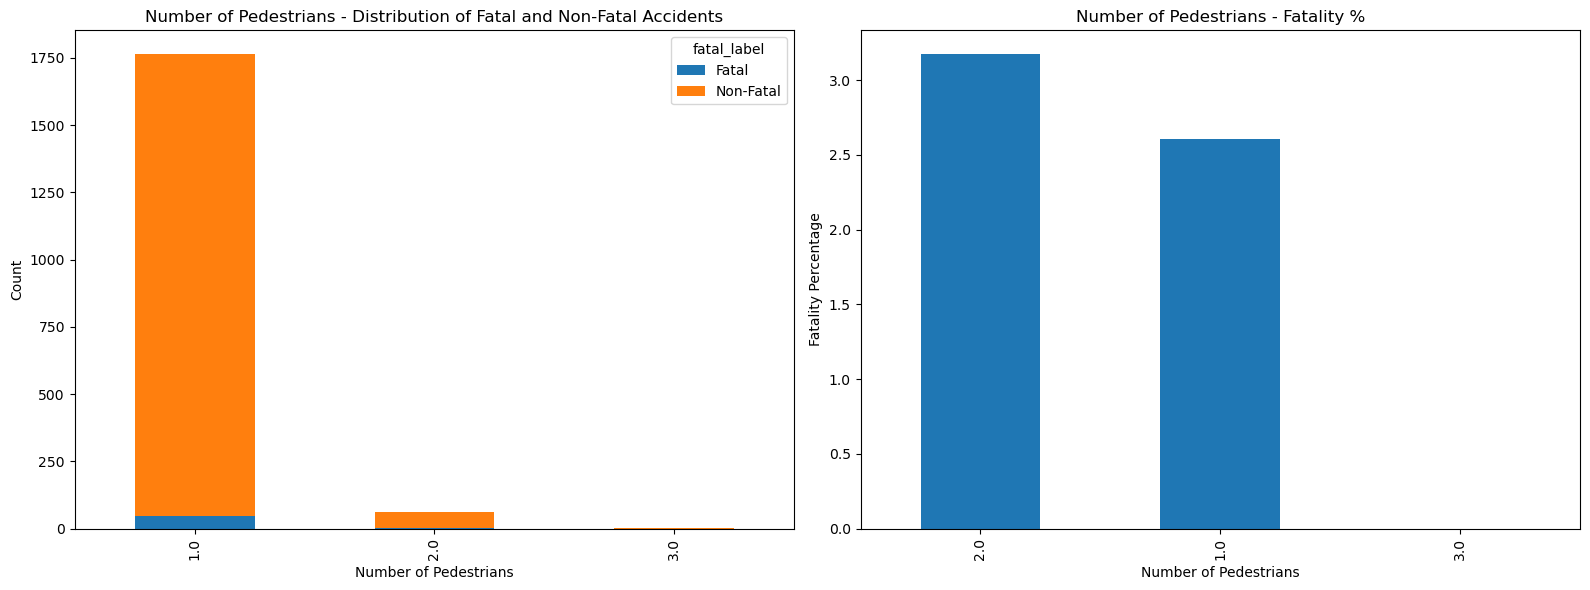


Number of Bicycles vs. Fatality --------------------------------------------------
fatal_label      Fatal  Non-Fatal  Fatality Percentage
num_of_bicycles                                       
1.0                 10       1641                 0.61
2.0                  0         12                 0.00
3.0                  0          2                 0.00


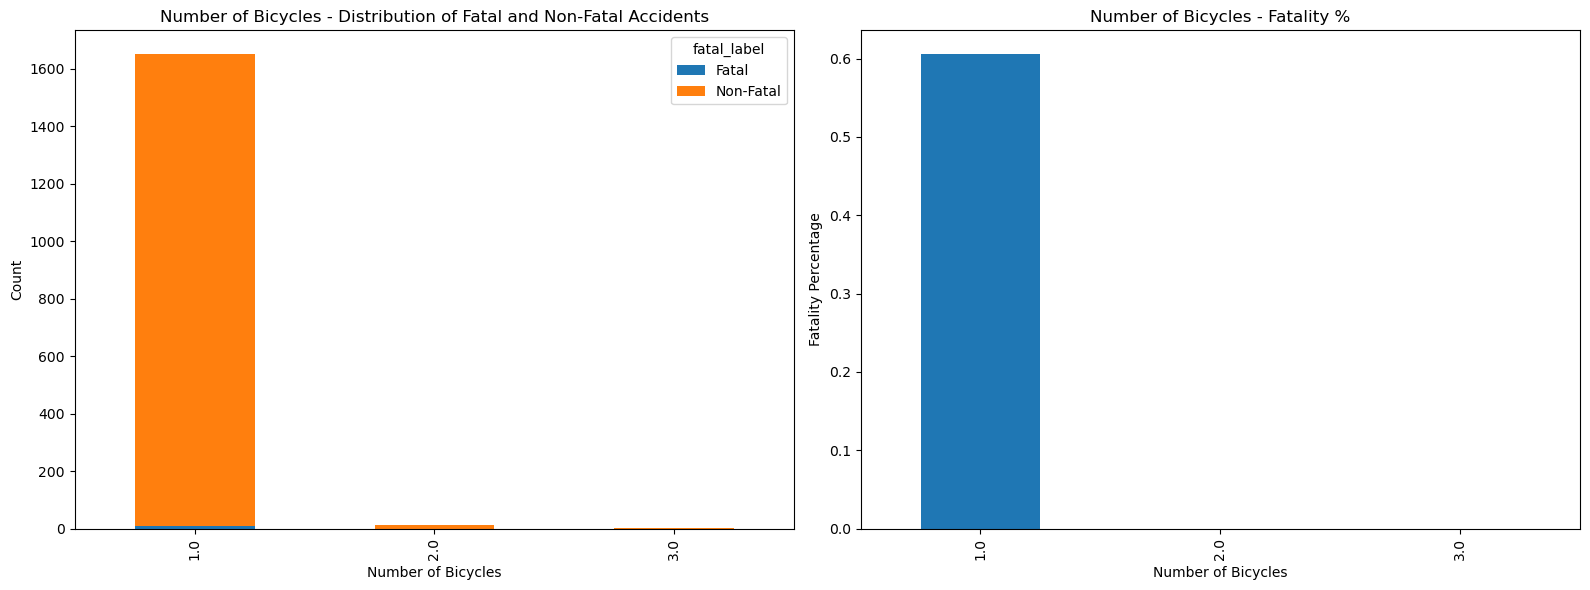


Number of Motorcycles vs. Fatality --------------------------------------------------
fatal_label         Fatal  Non-Fatal  Fatality Percentage
num_of_motorcycles                                       
1.0                    21        759                 2.69
2.0                     1          9                10.00
3.0                     0          1                 0.00


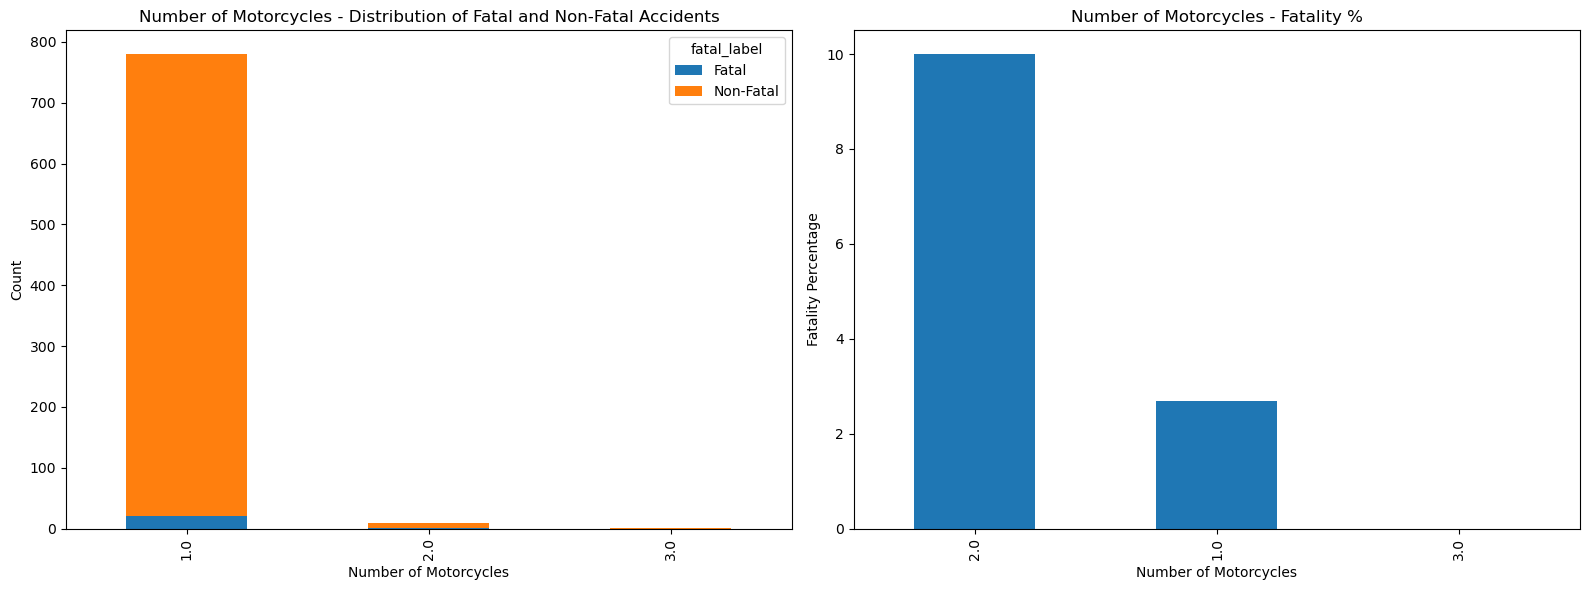

In [17]:
features = [
    ("Environment", "Environment_Condition_1"),
    ("Road Surface", "Road_1_Surface_Condition"),
    ("Lighting", "Light"),
    ("Impact Type", "Initial_Impact_Type"),
    ("Traffic Control", "Traffic_Control"),
    ("Number of Vehicles", "num_of_vehicles"), 
    ("Number of Pedestrians", "num_of_pedestrians"),
    ("Number of Bicycles", "num_of_bicycles"),
    ("Number of Motorcycles", "num_of_motorcycles")
]

target = 'fatal_label'

for name, col in features:
    
    print(f"\n{name} vs. Fatality --------------------------------------------------")
    
    # Crosstab
    table = pd.crosstab(df[col], df[target])
    
    # Fatal Percentage
    table['Fatality Percentage'] = table['Fatal'] / table.sum(axis=1) * 100 #sums across columns for each row
    
    print(table.round(2))
    
    # Sort for count plot by total count
    count_table = table.drop(columns=['Fatality Percentage']).copy()
    count_table = count_table.loc[count_table.sum(axis=1).sort_values(ascending=False).index]
    
    # Sort for fatal percentage plot
    percent_table = table.sort_values(by='Fatality Percentage', ascending=False)
    
    # Subplots
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    
    count_table.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title(f"{name} - Distribution of Fatal and Non-Fatal Accidents")
    axes[0].set_xlabel(name)
    axes[0].set_ylabel("Count")
    
    percent_table['Fatality Percentage'].plot(kind='bar', ax=axes[1])
    axes[1].set_title(f"{name} - Fatality %")
    axes[1].set_xlabel(name)
    axes[1].set_ylabel("Fatality Percentage")
    
    plt.tight_layout()
    plt.show()

### The bar graphs illustrate how frequently accidents occur and how they are distributed between fatal and non-fatal cases, while the fatality percentage bar graphs indicate the likelihood of fatal outcomes. Together, they help identify high-risk conditions.

### **For environmental conditions:**
- Most accidents occur under dry and wet environmental conditions. However, the fatality percentage is higher for conditions involving loose sand or gravel, as well as cases labeled as unknown, indicating these situations are more dangerous despite being less common.

**For environmental conditions:**
- The majority of accidents occur on dry and wet road surfaces. Similar to environmental conditions, higher fatality percentages are observed for loose sand or gravel and unknown surface conditions, reinforcing the pattern that less common conditions may pose greater risk.

**For lighting conditions:**
- Most accidents occur during daylight and dark conditions with street lighting. However, the fatality percentage is higher for accidents occurring in darkness without adequate lighting and during dusk, suggesting that reduced visibility increases the likelihood of severe outcomes.

**For impact conditions:**
- Rear-end collisions are the most common type of accident. However, collisions involving approaching vehicles (for example,  head-on accidents) have a higher fatality percentage, even though they occur less frequently, indicating they are significantly more severe.

**For traffic control conditions:**
- Most accidents occur in areas without traffic control, followed by locations with traffic signals and stop signs. However, accidents involving traffic gates exhibit a higher fatality percentage, despite being relatively rare, highlighting them as high-risk scenarios.

**For number of vehicles:**
- Most accidents involve two vehicles, followed by single-vehicle collisions. However, single-vehicle accidents have the highest fatality percentage, indicating they are more severe despite being less frequent than two-vehicle crashes. 

**For number of pedestrians:**
- Most accidents involve one pedestrian when pedestrians are present, while cases involving multiple pedestrians are relatively rare. However, the fatality percentage increases when more pedestrians are involved (for example, higher for two pedestrians than one). This suuggests that accidents involving multiple pedestrians tend to be more severe.

**For number of bicycles:**
- The majority of accidents involving bicycles include only one bicycle. Accidents involving a single bicycle show a noticeable fatality percentage, indicating elevated risk compared to many other conditions. However, cases with multiple bicycles show no fatalities in this dataset, likely due to extremely small sample sizes rather than indicating lower risk.

**For number of motorcycles:**
- Most accidents involving motorcycles include a single motorcycle, and these already show a relatively high fatality percentage, highlighting the vulnerability of motorcyclists. Accidents involving two motorcycles exhibit an even higher fatality percentage.

## Injury Severity Analysis

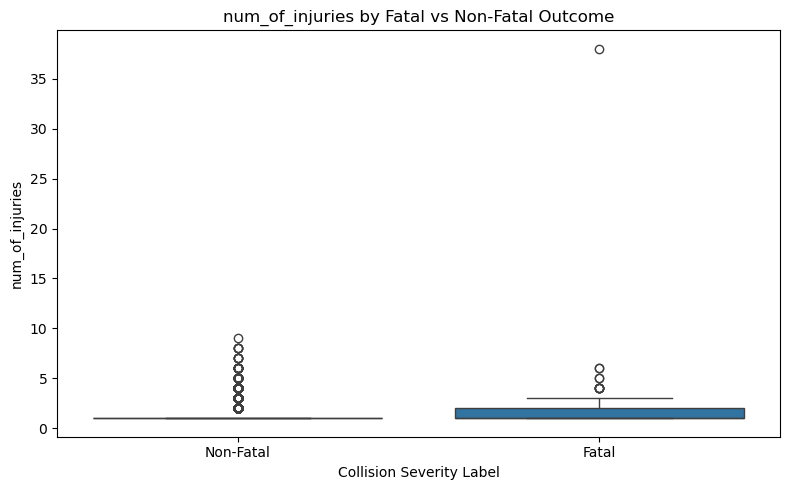

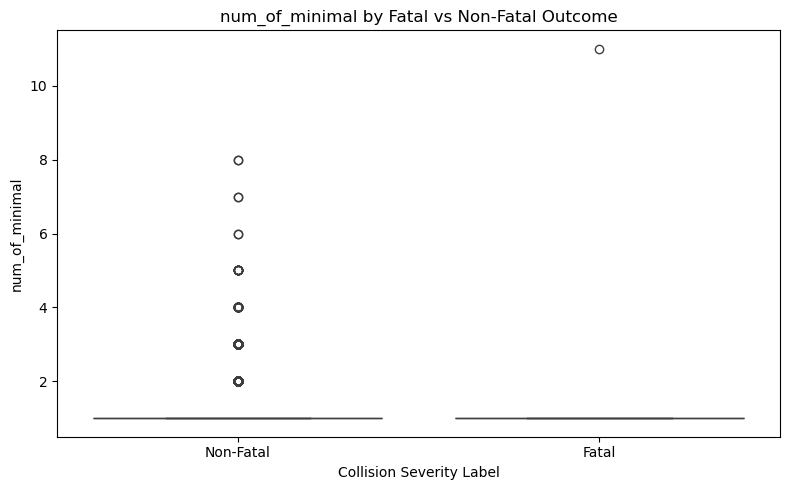

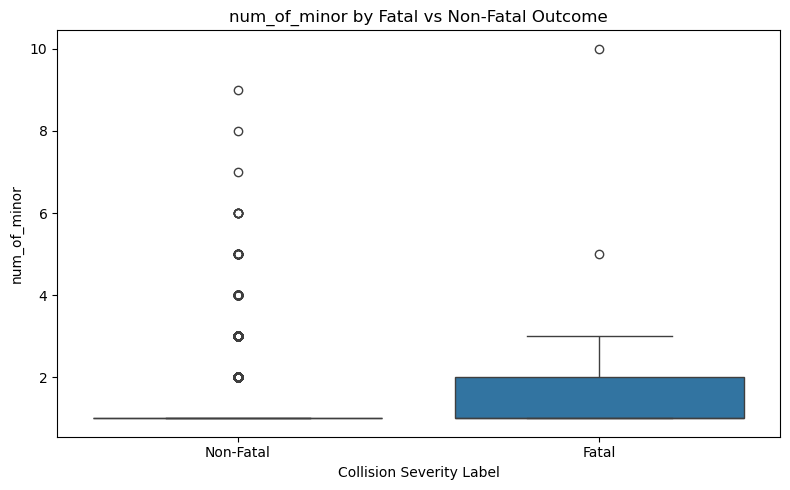

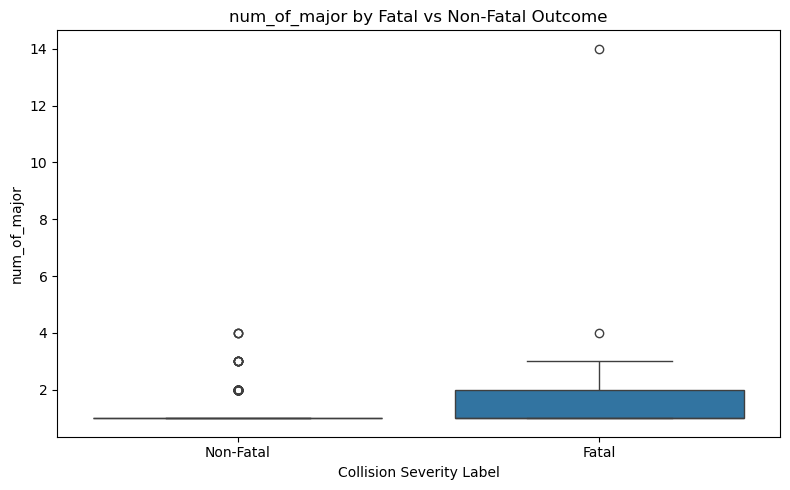

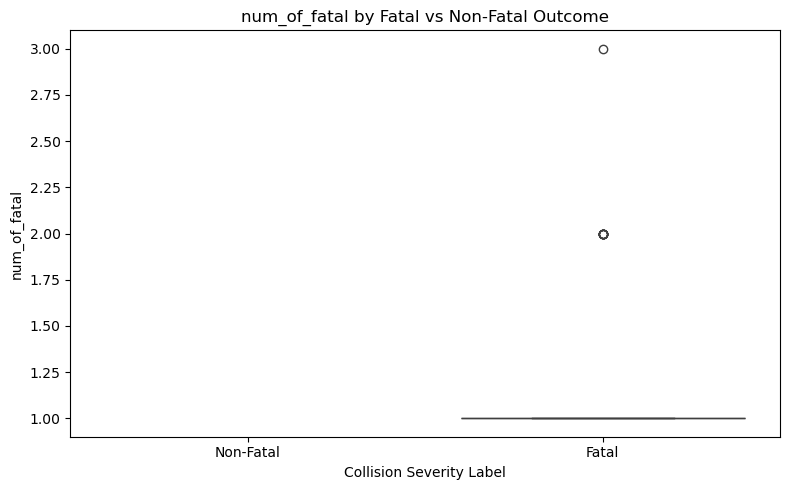

In [18]:
injury_features = ['num_of_injuries', 'num_of_minimal', 'num_of_minor', 'num_of_major', 'num_of_fatal']

for col in injury_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='fatal_label', y=col)
    plt.title(f"{col} by Fatal vs Non-Fatal Outcome")
    plt.xlabel("Collision Severity Label")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Fatal accidents are clearly associated with more severe injuries, especially major injuries, while minimal injuries provide little predictive value.
- Total injuries (num_of_injuries) tend to be higher in fatal accidents, indicating that more severe collisions involve greater overall harm.
- Minimal injuries (num_of_minimal) show little difference between fatal and non-fatal accidents, suggesting this feature is not strongly associated with accident severity.
- Minor injuries (num_of_minor) are slightly higher in fatal accidents, but the difference is not very pronounced.
- Major injuries (num_of_major) are significantly higher in fatal accidents, making this one of the strongest indicators of collision severity.
- The number of fatalities (num_of_fatal) directly determines whether an accident is classified as fatal, meaning this feature is highly predictive but may introduce data leakage if used in modeling.

## Correlation Analysis

In [19]:
df.corr(numeric_only=True)

,X,Y,X_Coordinate,Y_Coordinate,Accident_Year,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId,fatal_flag
X,1.000000,0.642976,0.989914,0.638701,-0.004861,0.068115,-0.000101,-0.011002,-0.036409,0.010007,0.000814,0.020975,-0.023941,-0.013521,0.638139,1.000000,-0.014241,-0.002268
Y,0.642976,1.000000,0.744297,0.999903,-0.015243,0.026167,0.007371,0.002494,-0.073413,0.009623,0.012462,0.004955,0.009420,0.005758,0.999896,0.642976,-0.017325,-0.000283
X_Coordinate,0.989914,0.744297,1.000000,0.740757,-0.006735,0.063233,0.001631,-0.007854,-0.035953,0.011327,0.003850,0.020722,-0.024010,-0.013566,0.740269,0.989914,-0.015344,-0.001682
Y_Coordinate,0.638701,0.999903,0.740757,1.000000,-0.015025,0.024703,0.007435,0.002743,-0.073581,0.010287,0.012906,0.005844,0.009246,0.005640,1.000000,0.638701,-0.017091,0.000017
Accident_Year,-0.004861,-0.015243,-0.006735,-0.015025,1.000000,0.068314,0.008973,0.036305,-0.009281,-0.030492,-0.048672,-0.041120,0.000954,-0.083001,-0.015026,-0.004861,0.978900,-0.000688
num_of_vehicles,0.068115,0.026167,0.063233,0.024703,0.068314,1.000000,0.006265,0.519099,0.119110,0.200955,0.162149,0.177147,0.054838,0.009694,0.024654,0.068115,0.064420,-0.025959
num_of_pedestrians,-0.000101,0.007371,0.001631,0.007435,0.008973,0.006265,1.000000,NaN,NaN,0.677823,0.496149,0.545968,0.049975,0.699544,0.007439,-0.000101,0.015674,0.002324
num_of_bicycles,-0.011002,0.002494,-0.007854,0.002743,0.036305,0.519099,NaN,1.000000,NaN,0.441752,0.383784,0.393108,NaN,NaN,0.002755,-0.011002,0.045568,-0.006842
num_of_motorcycles,-0.036409,-0.073413,-0.035953,-0.073581,-0.009281,0.119110,NaN,NaN,1.000000,0.069114,-0.031024,0.134125,NaN,1.000000,-0.073422,-0.036409,-0.010050,0.038755
num_of_injuries,0.010007,0.009623,0.011327,0.010287,-0.030492,0.200955,0.677823,0.441752,0.069114,1.000000,0.743364,0.764844,0.780413,0.593774,0.010290,0.010007,-0.032256,0.088311


## Build a heatmap to visualize correlations.

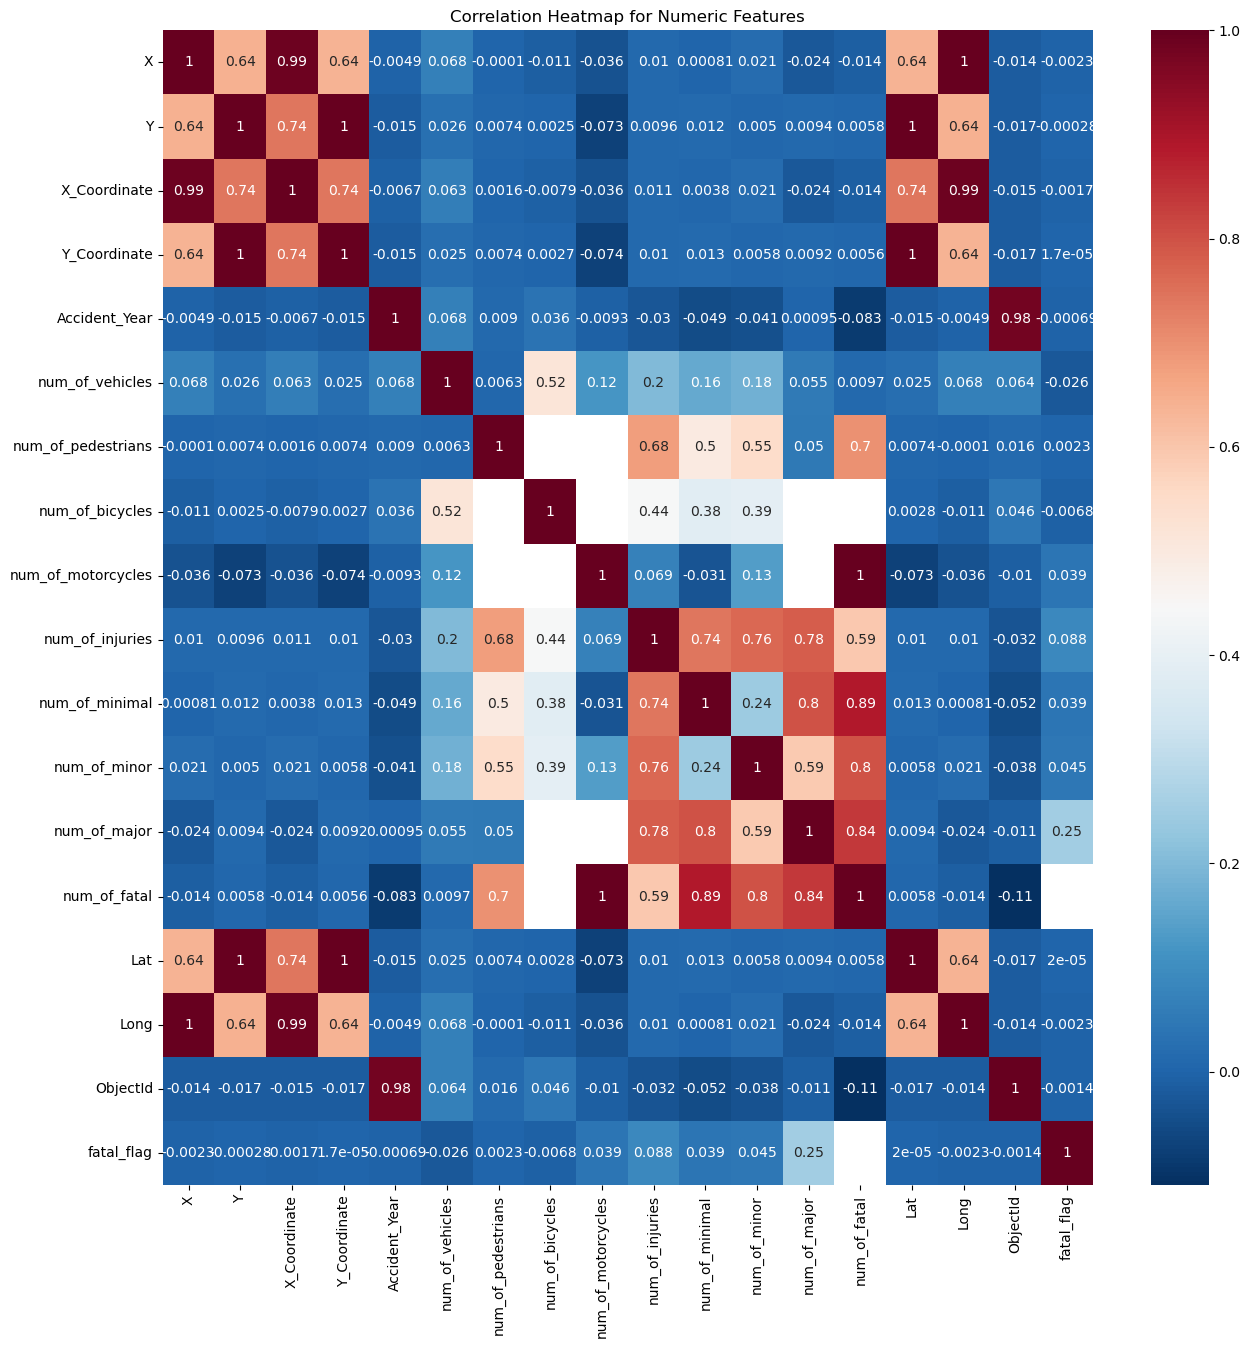

In [20]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

In [21]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

In [22]:
pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)): # to prevent duplicates
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        
        corr_value = corr_matrix.loc[col1, col2]
        
        if abs(corr_value) >= 0.7:
            pairs.append((col1, col2, corr_value))

corr_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation'])
corr_df['abs_correlation'] = corr_df['correlation'].abs() # to help order the correlation value

corr_df = corr_df.sort_values(by='abs_correlation', ascending=False)

print(f"There are {len(pairs)} features.")

corr_df

There are 18 features.


,feature_1,feature_2,correlation,abs_correlation
10,num_of_motorcycles,num_of_fatal,1.000000,1.000000
1,X,Long,1.000000,1.000000
8,Y_Coordinate,Lat,1.000000,1.000000
3,Y,Y_Coordinate,0.999903,0.999903
4,Y,Lat,0.999896,0.999896
7,X_Coordinate,Long,0.989914,0.989914
0,X,X_Coordinate,0.989914,0.989914
9,Accident_Year,ObjectId,0.978900,0.978900
15,num_of_minimal,num_of_fatal,0.888235,0.888235
17,num_of_major,num_of_fatal,0.838217,0.838217


## There are 18 features that are equal to or greater than the chosen threshold of 0.7.

The correlation analysis shows that there are many features that are highly correlated. This seems to indicate redundancy in the dataset. Geographic variables such as X, Y, latitude, and longitude have very strong correlations, only one pair should be kept. Also, injury-related variables are strongly correlated with each other. Additionally, ObjectId is highly correlated with Accident_Year, which means it does not provide useful information and can be removed. Reducing highly correlated features can improve model performance.

## Temporal Analysis

In [23]:
yearly_summary = (df.groupby("Accident_Year").agg(total_collisions=("Accident_Year", "size"), fatal_collisions=("fatal_flag", "sum")).reset_index())

# Fatal rate
yearly_summary["fatal_rate"] = (yearly_summary["fatal_collisions"] / yearly_summary["total_collisions"])

# Keep only needed columns
yearly_summary = yearly_summary[["Accident_Year", "total_collisions", "fatal_collisions", "fatal_rate"]]

# Display
display(yearly_summary.style.format({"fatal_rate": "{:.2%}",}))

,Accident_Year,total_collisions,fatal_collisions,fatal_rate
0,2017,14424,28,0.19%
1,2018,14556,26,0.18%
2,2019,16465,25,0.15%
3,2020,10067,18,0.18%
4,2021,9748,23,0.24%
5,2022,12490,23,0.18%
6,2024,16656,27,0.16%


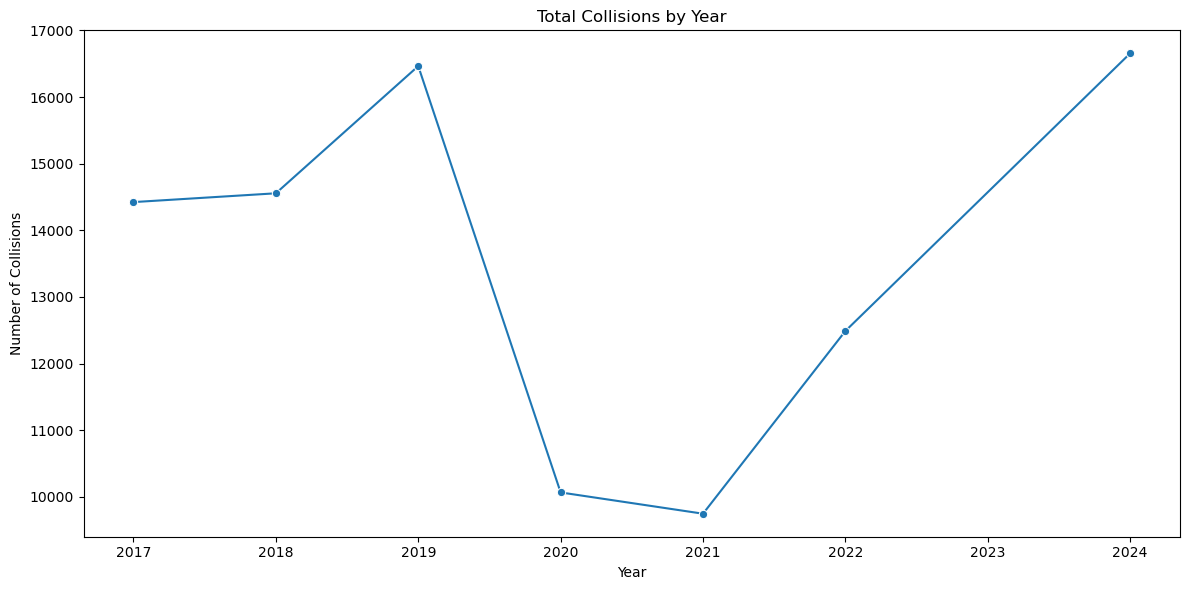

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=yearly_summary, x="Accident_Year", y="total_collisions", marker="o", ax=ax)
ax.set_title("Total Collisions by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Collisions")
plt.tight_layout()
plt.show()

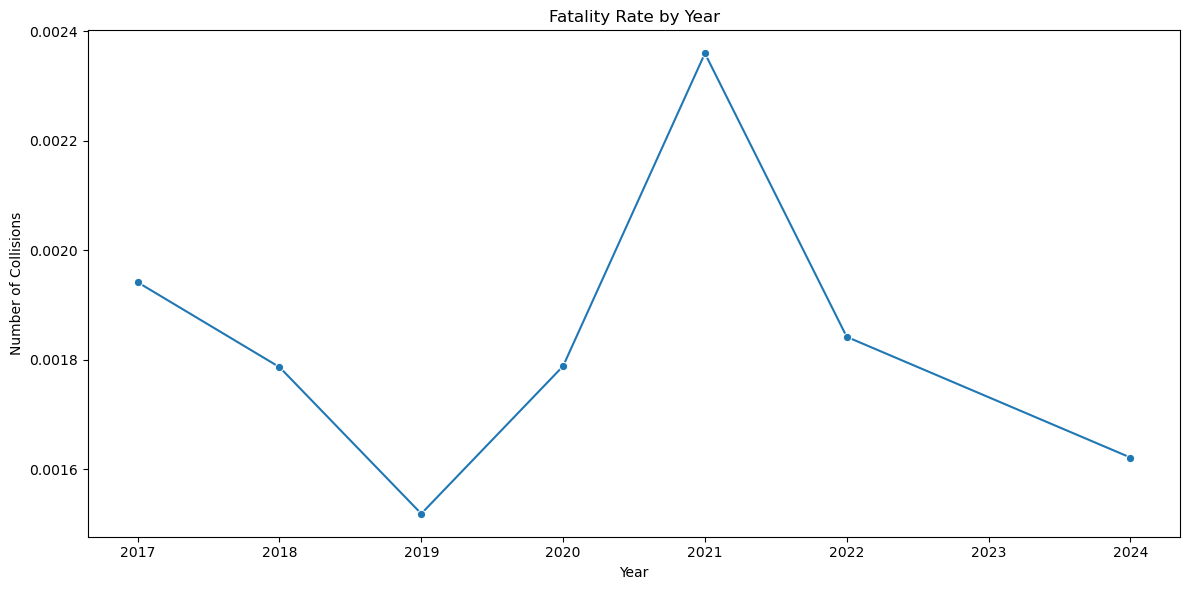

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=yearly_summary, x="Accident_Year", y="fatal_rate", marker="o", ax=ax)
ax.set_title("Fatality Rate by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Collisions")
plt.tight_layout()
plt.show()

### We see that in 2020–2021 (during the peak of the pandemic), collision numbers were at their lowest. However, the fatality rate reached its highest point in 2021 at 0.24%, suggesting that factors beyond the collision volume play a more significant role. With fewer vehicles on the road, drivers may have traveled at higher speeds, particularly on highways or less congested routes, leading to more severe outcomes. After 2021, collision numbers gradually returned to pre-pandemic levels, while fatality rates stabilized. 

In [26]:
df["Accident_Date"] = pd.to_datetime(df["Accident_Date"])
df["Month_Name"] = df["Accident_Date"].dt.month_name()

In [27]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_summary = (
    df.groupby("Month_Name")
    .agg(
        total_collisions=("Month_Name", "size"),
        fatal_collisions=("fatal_flag", "sum"),
    )
    .reindex(month_order)
    .reset_index()
)

# Fatal rate
monthly_summary["fatal_rate"] = (
    monthly_summary["fatal_collisions"] / monthly_summary["total_collisions"]
)

monthly_summary = monthly_summary[
    ["Month_Name", "total_collisions", "fatal_collisions", "fatal_rate"]
]

display(monthly_summary.style.format({
    "fatal_rate": "{:.2%}",
}))

,Month_Name,total_collisions,fatal_collisions,fatal_rate
0,January,9849,15,0.15%
1,February,8856,12,0.14%
2,March,6824,11,0.16%
3,April,5545,14,0.25%
4,May,6889,14,0.20%
5,June,7077,12,0.17%
6,July,7062,24,0.34%
7,August,6961,16,0.23%
8,September,7970,20,0.25%
9,October,8358,8,0.10%


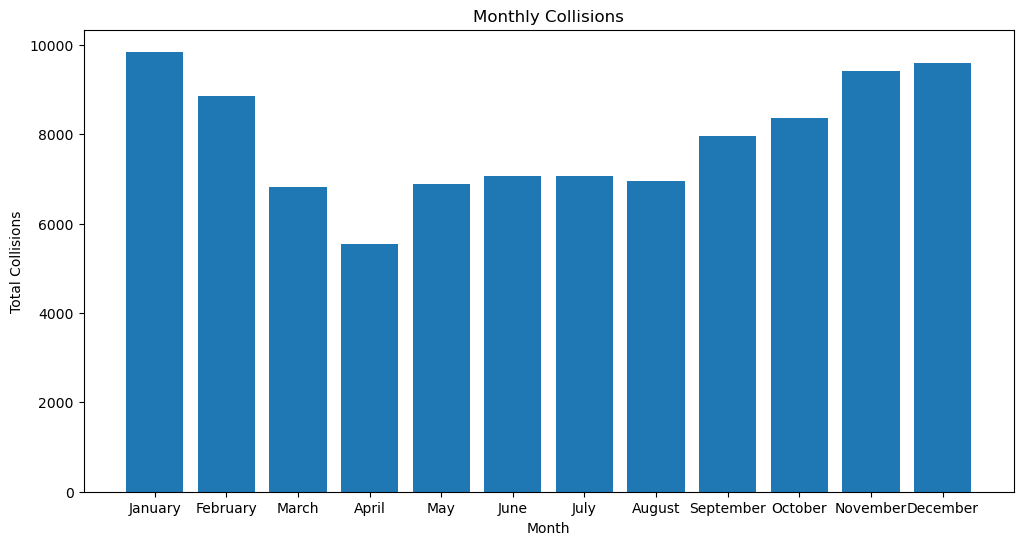

In [28]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar plot (total collisions)
ax1.bar(monthly_summary["Month_Name"], monthly_summary["total_collisions"])
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Collisions")

plt.title("Monthly Collisions")
plt.show()

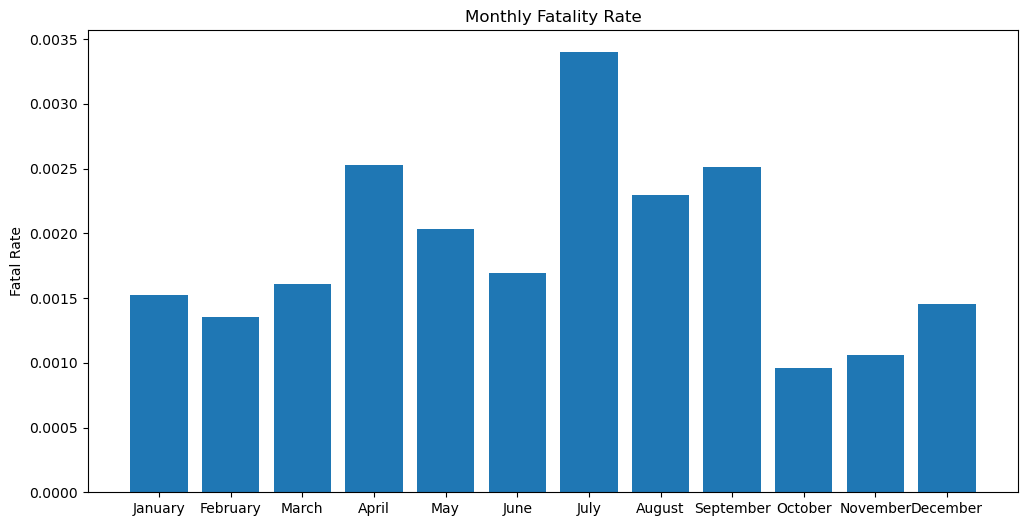

In [29]:
fig, ax1 = plt.subplots(figsize=(12,6))

# bar plot (fatal rate)
ax1.bar(monthly_summary["Month_Name"], monthly_summary["fatal_rate"])
ax1.set_ylabel("Fatal Rate")

plt.title("Monthly Fatality Rate")
plt.show()

### We see that collision frequency is highest during the winter months (November–January), probably due to weather conditions such as snow and ice, while spring months, particularly April, show the lowest collision counts. Fatal collisions tend to peak in the summer, especially in July at 0.35%, even though total collisions are not at their highest during this period. For summer, this may be explained by higher driving speeds in clear conditions, increased travel, and greater exposure of road users such as pedestrians and cyclists.


In [30]:
df["Accident_Date"] = pd.to_datetime(df["Accident_Date"])
df["Day_Of_Week"] = df["Accident_Date"].dt.day_name()

In [31]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_summary = (
    df.groupby("Day_Of_Week")
    .agg(
        total_collisions=("Day_Of_Week", "size"),
        fatal_collisions=("fatal_flag", "sum"),
    )
    .reindex(dow_order)
    .reset_index()
)

# Fatal rate
dow_summary["fatal_rate"] = (dow_summary["fatal_collisions"] / dow_summary["total_collisions"])

display(dow_summary.style.format({
    "fatal_rate": "{:.2%}",
}))

,Day_Of_Week,total_collisions,fatal_collisions,fatal_rate
0,Monday,12809,26,0.20%
1,Tuesday,14630,25,0.17%
2,Wednesday,14973,18,0.12%
3,Thursday,15454,27,0.17%
4,Friday,16177,36,0.22%
5,Saturday,11416,15,0.13%
6,Sunday,8947,23,0.26%


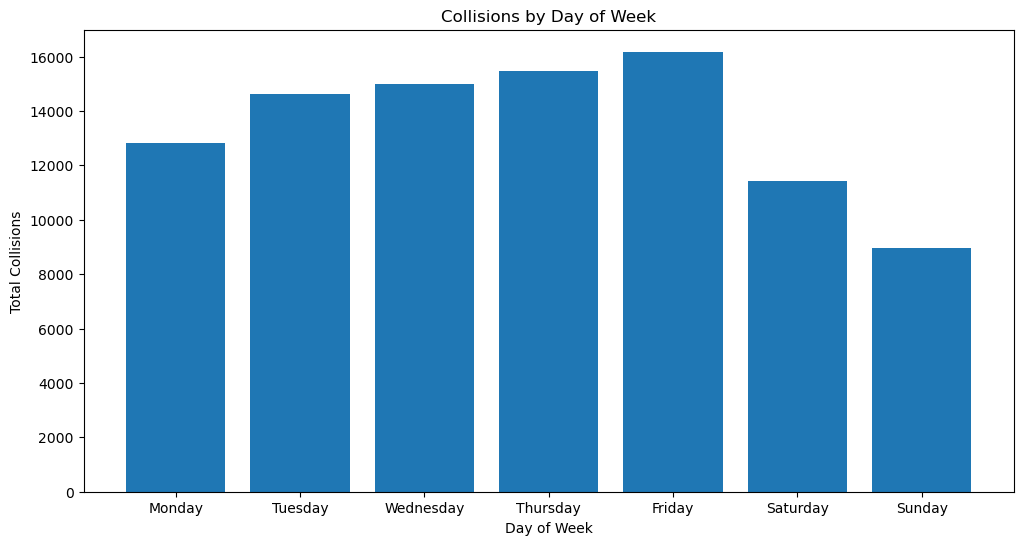

In [32]:
fig, ax1 = plt.subplots(figsize=(12,6))

dow_summary = (
    df.groupby("Day_Of_Week")
    .agg(
        total_collisions=("Day_Of_Week", "size"),
        fatal_collisions=("fatal_flag", "sum")
    )
    .reindex(dow_order)
    .reset_index()
)

dow_summary["fatal_rate"] = (
    dow_summary["fatal_collisions"] / dow_summary["total_collisions"]
)

dow_summary = dow_summary[
    ["Day_Of_Week", "total_collisions", "fatal_collisions", "fatal_rate"]
]

# Plot
ax1.bar(dow_summary["Day_Of_Week"], dow_summary["total_collisions"])
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Total Collisions")

plt.title("Collisions by Day of Week")
plt.show()

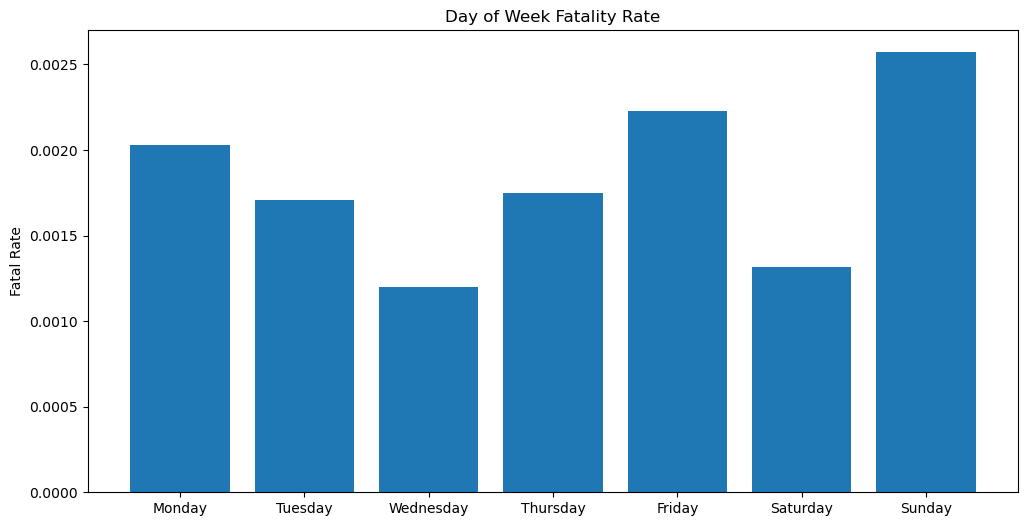

In [33]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(dow_summary["Day_Of_Week"], dow_summary["fatal_rate"])
ax1.set_ylabel("Fatal Rate")

plt.title("Day of Week Fatality Rate")
plt.show()

### We observe that collision frequency is highest on weekdays, particularly toward the end of the workweek (Thursday–Friday), and lowest on weekends, especially Sunday. However, the fatality rate is highest on Sunday (0.26%). This suggests that while fewer collisions occur on weekends, they tend to be more severe. Possible explanations include higher travel speeds, lower traffic congestion, and increased likelihood of impaired driving.

## Location/ Hotspot Analysis

In [34]:
# Top locations by total collisions
top_total_locations = (df["Location"].fillna("Unknown").value_counts().head(20).rename_axis("Location").reset_index(name="collision_count"))

display(top_total_locations)

,Location,collision_count
0,Unknown,2076
1,HIGHWAY 417 btwn HWY417 IC124 RAMP65 & HWY417 ...,521
2,HUNT CLUB RD @ RIVERSIDE DR (0002237),334
3,ST. JOSEPH BLVD @ JEANNE D'ARC BLVD (0012421),329
4,HIGHWAY 417 btwn HWY417 IC122 RAMP15 & HWY417 ...,232
5,HIGHWAY 417 btwn HWY417 IC122 RAMP61 & HWY417 ...,231
6,PRINCE OF WALES DR @ WEST HUNT CLUB RD (0000567),229
7,WEST HUNT CLUB RD @ WOODROFFE AVE (0000576),226
8,HIGHWAY 417 btwn HWY417 IC126 RAMP25 & HWY417 ...,222
9,INNES RD @ TENTH LINE RD (0004633),219


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94406 entries, 0 to 94405
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   X                           94406 non-null  float64       
 1   Y                           94406 non-null  float64       
 2   X_Coordinate                94406 non-null  float64       
 3   Y_Coordinate                94406 non-null  float64       
 4   ID                          94406 non-null  object        
 5   Geo_ID                      92330 non-null  object        
 6   Accident_Year               94406 non-null  int64         
 7   Accident_Date               94406 non-null  datetime64[ns]
 8   Location                    92330 non-null  object        
 9   Classification_Of_Accident  94406 non-null  object        
 10  Initial_Impact_Type         94394 non-null  object        
 11  Road_1_Surface_Condition    94405 non-null  object    

In [36]:
# Top locations by fatalilties
top_severe_locations = (df[df["fatal_flag"] == 1]["Location"].fillna("Unknown").value_counts().head(20).rename_axis("Location").reset_index(name="fatal_collision_count"))

display(top_severe_locations)

,Location,fatal_collision_count
0,BANK ST btwn RIDGEMONT AVE & PORTLAND AVE (__3...,2
1,ALBION RD @ MITCH OWENS RD (0004212),2
2,REGIONAL ROAD 174 btwn EAST ST & EAST SHORE RD...,2
3,8TH LINE RD @ PARKWAY RD (0001611),2
4,RUSSELL RD @ SOUTHVALE CRES N (0002650),2
5,MCCORDICK RD @ ROGER STEVENS DR (0003719),2
6,HIGHWAY 417 btwn HWY417 IC140 RAMP35 & HWY417 ...,2
7,HIGHWAY 417 btwn HWY417 IC119B RAMP76 & HWY417...,1
8,SNAKE ISLAND RD btwn NIXON DR & DOYLE RD (__3Z...,1
9,GALETTA SIDE RD btwn UPPER DWYER HILL RD & HIG...,1


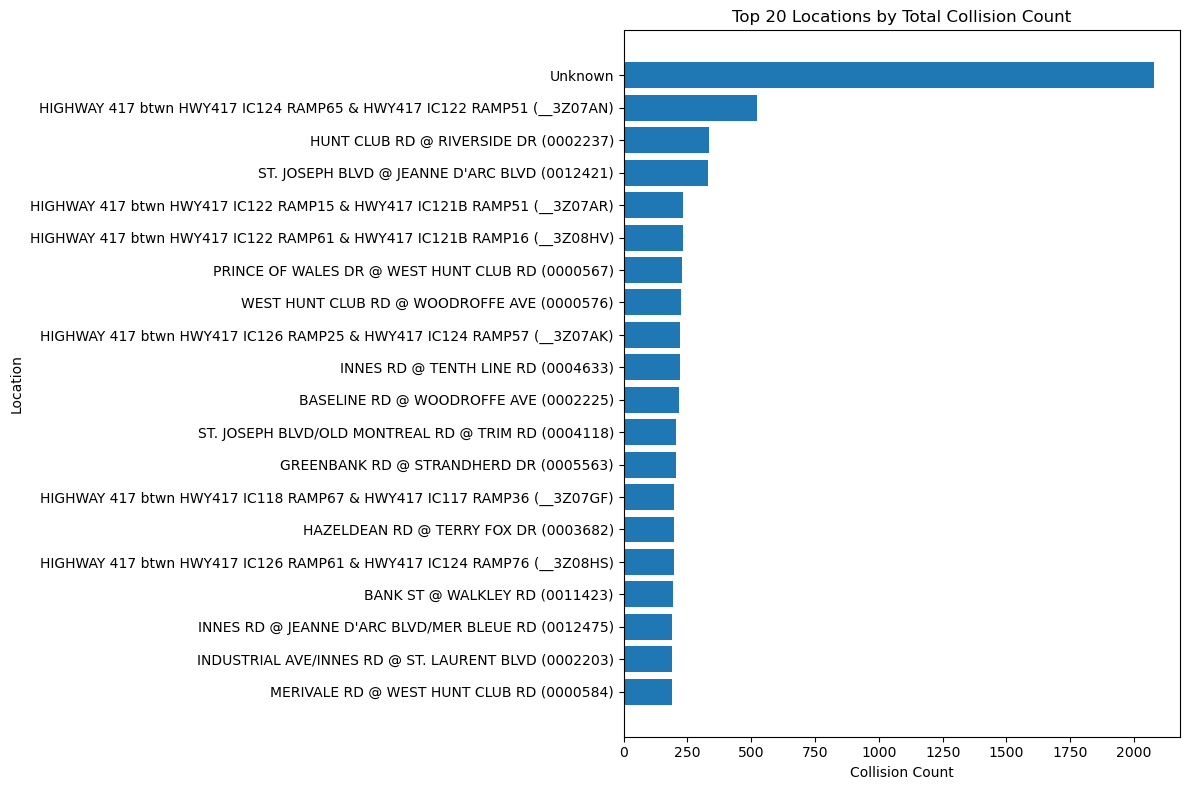

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
plot_data = top_total_locations.sort_values("collision_count", ascending=True)
ax.barh(plot_data["Location"], plot_data["collision_count"])
ax.set_title("Top 20 Locations by Total Collision Count")
ax.set_xlabel("Collision Count")
ax.set_ylabel("Location")
plt.tight_layout()
plt.show()

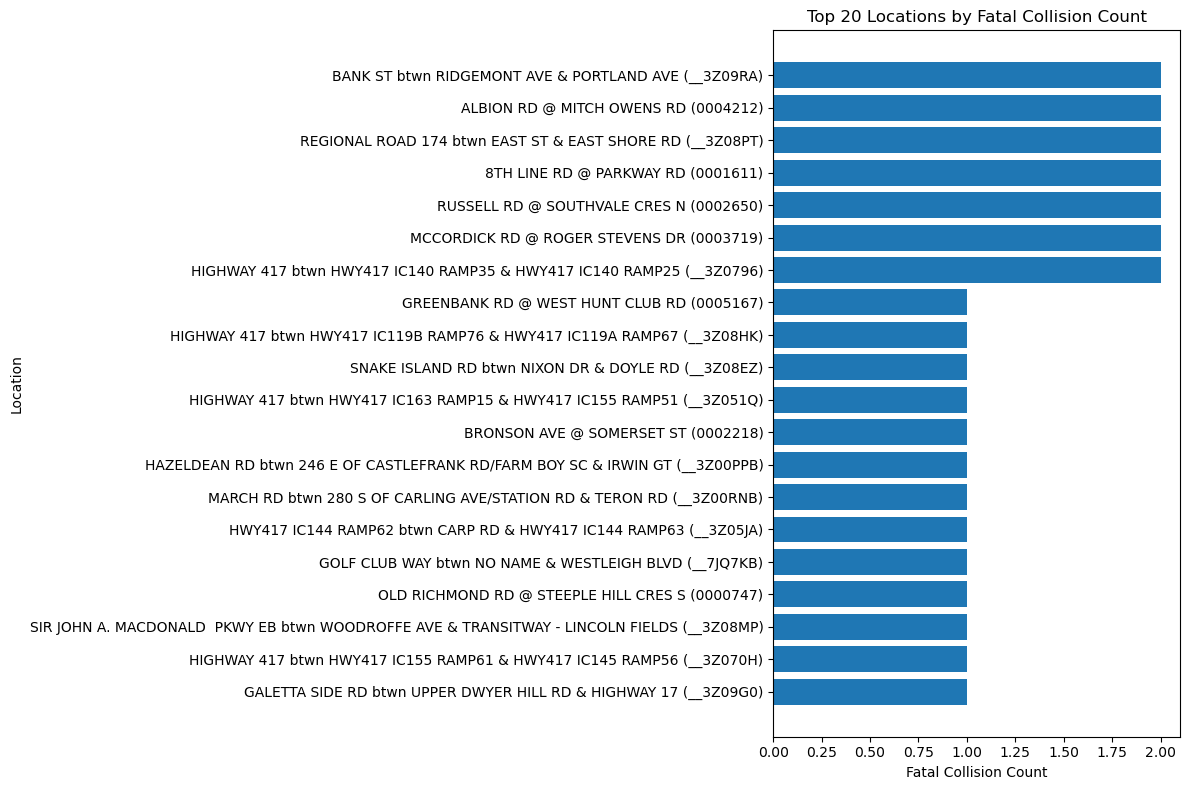

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))
plot_data = top_severe_locations.sort_values("fatal_collision_count", ascending=True)
ax.barh(plot_data["Location"], plot_data["fatal_collision_count"])
ax.set_title("Top 20 Locations by Fatal Collision Count")
ax.set_xlabel("Fatal Collision Count")
ax.set_ylabel("Location")
plt.tight_layout()
plt.show()


### We observe that unknown sites actually came up as first 2076 total collisions.  HIGHWAY 417 btwn HWY417 IC124 RAMP65 & HWY417, HUNT CLUB RD @ RIVERSIDE DR (0002237) and ST. JOSEPH BLVD @ JEANNE D'ARC BLVD (0012421) are the top 3 other sites for collisions. Then there are 6 sites with the highest number of fatal collisions being 2 fatalities. These areas represent major roads and busy intersections. No single location stands out as a dominant hotspot. Fatal collisions seem to be influenced more by situational factors.


## Recommendations for the Next Stages

### Class Imbalance
- Fatal collisions are extremely rare, so raw accuracy alone will be misleading.
- For binary rare-event models, consider:
    - class_weight="balanced" - to automatically adjust for class imbalance during training
    - stratified train/test split - to preserve the proportion of fatal and non-fatal cases in both sets
    - Consider resampling techniques such as SMOTE, SMOTE-ENN, or ADASYN, applied carefully after data splitting to avoid data leakage

### Metrics
- Precision-Recall Area Under the Curve (PR-AUC) – evaluates performance on the minority (fatal) class
- Matthews Correlation Coefficient (MCC) – a balanced metric that accounts for all confusion matrix outcomes
- F1-score – harmonic mean of precision and recall
- Precision (Fatal class) – proportion of correctly predicted fatal collisions
- Recall (Fatal class) – ability to detect actual fatal collisions
- True Negative Rate (TNR) – ability to correctly identify non-fatal collisions
- Balanced Accuracy – average of recall (sensitivity) and specificity (true negative rate)

### Predictors
Useful predictors from this dataset include:

strong
- road surface condition
- environment condition
- light condition
- initial impact type
- number of vehicles
- number of pedestrians
- number of bicycles
- number of injuries
- number of minor injuries
  
medium 
- traffic control
- month/season/day of week
- number of minimal injuries

### Features to Exclude
- num_of_fatal
- possibly num_of_major

### Feature Reduction
Remove redundant variables, especially coordinate duplicates:
- X vs. X_Coordinate
- Y vs. Y_Coordinate
- latitude / longitude vs projected coordinate systems

### Temporal Limitation
- The provided CSV does not include time (of day).